# Phase 1 EDA — Data Sanity Checks

SPEC.md Section 13, Phase 1: *"Raw data pulled and cached; sanity-check EPA
distributions, home win rate, score distributions against known football facts —
confirms the data is trustworthy before building on it."*

This notebook is **read-only exploration**. No feature engineering happens here
(that is Phase 2, governed by SPEC Section 5). It reads the cached raw pulls in
`data/raw/` produced by `python -m src.data_ingest`.

Scope follows SPEC Section 15: **regular-season games only**, completed games
only (2026 is scheduled but unplayed and is excluded automatically).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"

schedules = pd.concat(
    [pd.read_parquet(p) for p in sorted(RAW.glob("schedules_*.parquet"))],
    ignore_index=True,
)
pbp = pd.concat(
    [pd.read_parquet(p) for p in sorted(RAW.glob("pbp_*.parquet"))],
    ignore_index=True,
)

print("schedules:", schedules.shape, "| seasons",
      int(schedules.season.min()), "-", int(schedules.season.max()))
print("pbp      :", pbp.shape, "| seasons",
      int(pbp.season.min()), "-", int(pbp.season.max()))
schedules.game_type.value_counts()

schedules: (6771, 46) | seasons 2002 - 2026
pbp      : (1143032, 398) | seasons 2002 - 2025


REG    6495
WC      108
DIV      96
CON      48
SB       24
Name: game_type, dtype: int64

In [2]:
# Completed regular-season games only (SPEC Section 15).
reg = schedules[schedules.game_type == "REG"].copy()
played = reg.dropna(subset=["home_score", "away_score"]).copy()

played["home_margin"] = played.home_score - played.away_score
played["total_points"] = played.home_score + played.away_score
played["home_win"] = np.where(
    played.home_margin > 0, 1,
    np.where(played.home_margin < 0, 0, np.nan),  # ties -> NaN
)
n_ties = int(played.home_margin.eq(0).sum())
print(f"REG games with final scores: {len(played):,}  (incl. {n_ties} ties)")
print(f"seasons with results       : {int(played.season.min())}-{int(played.season.max())}")

REG games with final scores: 6,223  (incl. 15 ties)
seasons with results       : 2002-2025


## Check 1 — Home win rate (by span)

**What this confirms:** that "home team wins ~55–58% of the time" holds in our
data, so the naive *always-pick-home* baseline (SPEC Section 2) is sensible — and
that we read the right baseline for the **split we actually test on**.

SPEC Section 2 quotes a historical ~57–58%. Home-field advantage has measurably
declined since 2019 (crowd-free 2020, travel/recovery science, officiating
shifts): the 2023–2024 **test** seasons sit near **54%**, not 58%. The model's
"beat baseline" bar is computed per-split by
`src.evaluate.home_baseline_accuracy`, not hardcoded.

In [3]:
import sys
sys.path.insert(0, str(ROOT))
from src.evaluate import home_baseline_accuracy, season_range

spans = {
    "all 2002-2025":       None,
    "train 2002-2021":     season_range(2002, 2021),
    "val 2022":            season_range(2022, 2022),
    "test 2023-2024":      season_range(2023, 2024),
    "2025":                season_range(2025, 2025),
}
rows = []
for label, yrs in spans.items():
    r = home_baseline_accuracy(schedules, yrs)
    rows.append((label, r["baseline_accuracy"], r["home_wins"], r["n_games"]))
pd.DataFrame(rows, columns=["span", "home_win_rate", "home_wins", "n_games"]).round(4)

,span,home_win_rate,home_wins,n_games
0,all 2002-2025,0.5611,3483,6208
1,train 2002-2021,0.5640,2890,5124
2,val 2022,0.5613,151,269
3,test 2023-2024,0.5441,296,544
4,2025,0.5387,146,271


In [4]:
# Per-season, to see the post-2019 dip directly.
by_season = (
    played.dropna(subset=["home_win"])
          .groupby("season").home_win.agg(["mean", "count"])
          .rename(columns={"mean": "home_win_rate", "count": "n_games"})
)
by_season.round(3)

,home_win_rate,n_games
season,,
2002,0.580,255
2003,0.613,256
2004,0.566,256
2005,0.590,256
2006,0.531,256
2007,0.574,256
2008,0.573,255
2009,0.570,256
2010,0.559,256


**Read:** overall ~0.561, training span ~0.564, but 2019–2021 dip into the low
0.50s (2020 = 0.498) and the 2023–2024 test span is ~0.544. Consistent with the
documented HFA decline — not a data problem.

## Check 2 — Score distribution

**What this confirms:** scoring levels match known NFL facts —
- average total points **~44–46** (SPEC Section 12.2),
- average home margin **~2.5** (home-field advantage, SPEC Section 12.1),
- home team outscores away on average,
- margin spread is wide (std ~14) — a single turnover ≈ one score (SPEC 12.1).

In [5]:
dist = played[["home_score", "away_score", "total_points", "home_margin"]].describe(
    percentiles=[.05, .25, .5, .75, .95]
).T[["mean", "std", "5%", "25%", "50%", "75%", "95%"]]
dist.round(2)

,mean,std,5%,25%,50%,75%,95%
home_score,23.36,10.24,7.0,17.0,23.0,30.0,41.0
away_score,21.17,10.05,6.0,14.0,21.0,28.0,38.0
total_points,44.53,14.03,23.0,35.0,44.0,53.0,69.0
home_margin,2.19,14.64,-23.0,-7.0,3.0,10.0,28.0


In [6]:
print(f"avg total points : {played.total_points.mean():.2f}   (SPEC 12.2: ~44-46)")
print(f"avg home margin  : {played.home_margin.mean():.2f}   (SPEC 12.1: ~2.5 HFA)")
print(f"avg home score   : {played.home_score.mean():.2f}")
print(f"avg away score   : {played.away_score.mean():.2f}")

avg total points : 44.53   (SPEC 12.2: ~44-46)
avg home margin  : 2.19   (SPEC 12.1: ~2.5 HFA)
avg home score   : 23.36
avg away score   : 21.17


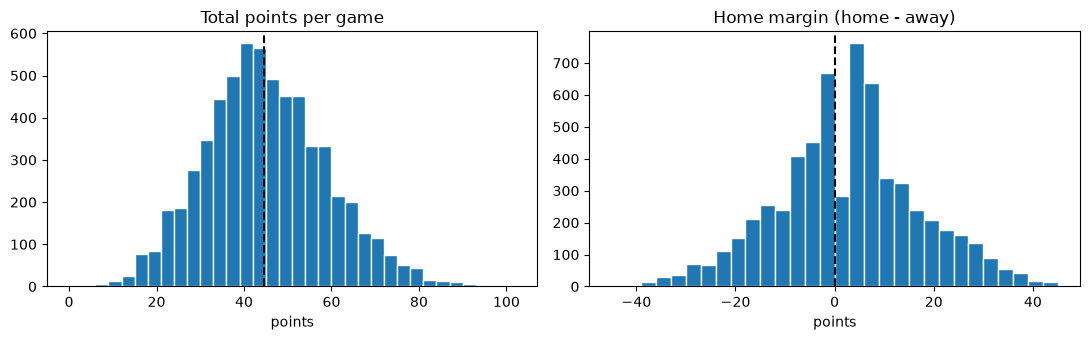

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(played.total_points, bins=range(0, 105, 3), edgecolor="white")
ax[0].axvline(played.total_points.mean(), color="k", ls="--")
ax[0].set_title("Total points per game"); ax[0].set_xlabel("points")
ax[1].hist(played.home_margin, bins=range(-45, 48, 3), edgecolor="white")
ax[1].axvline(0, color="k", ls="--")
ax[1].set_title("Home margin (home - away)"); ax[1].set_xlabel("points")
plt.tight_layout()

## Check 3 — EPA distribution

**What this confirms:** the EPA fields that every QB/defense feature in Phase 2
will be built on (SPEC Section 3.3) behave as expected —
- mean EPA per play **≈ 0** (EPA is centred by construction),
- **pass plays out-gain rush plays** in mean EPA (a bedrock NFL analytics fact),
- **CPOE ≈ 0** on average (it is "over expected"),
- **3rd down** is the toughest down by EPA — the "money-down" signal SPEC
  Section 3.3 wants a defensive feature for is visible in the raw data.

In [8]:
plays = pbp[pbp.epa.notna()].copy()
print(f"plays with non-null epa : {len(plays):,}")
print(f"mean epa (all plays)    : {plays.epa.mean():.4f}   (expect ~0)")
print(f"std  epa (all plays)    : {plays.epa.std():.4f}")
print(f"mean epa | pass attempt : {plays.loc[plays.pass_attempt == 1, 'epa'].mean():.4f}")
print(f"mean epa | rush attempt : {plays.loc[plays.rush_attempt == 1, 'epa'].mean():.4f}   (expect pass > rush)")
print(f"mean cpoe | pass plays  : {plays.loc[plays.pass_attempt == 1, 'cpoe'].mean():.4f} pp   (expect ~0)")

plays with non-null epa : 1,129,896
mean epa (all plays)    : -0.0066   (expect ~0)
std  epa (all plays)    : 1.2631
mean epa | pass attempt : 0.0134
mean epa | rush attempt : -0.0571   (expect pass > rush)
mean cpoe | pass plays  : 0.1217 pp   (expect ~0)


In [9]:
# EPA by down: early downs vs money downs.
plays.groupby("down").epa.agg(["mean", "count"]).round(4)

,mean,count
down,,
1.0,-0.0234,386188
2.0,-0.0022,290617
3.0,-0.0429,187200
4.0,-0.0184,100419


season
2002   -0.0303
2003   -0.0400
2004   -0.0216
2005   -0.0345
2006   -0.0479
2007   -0.0333
2008   -0.0197
2009   -0.0246
2010   -0.0212
2011   -0.0120
2012   -0.0034
2013   -0.0081
2014   -0.0202
2015   -0.0205
2016   -0.0017
2017   -0.0358
2018    0.0028
2019   -0.0104
2020    0.0237
2021   -0.0013
2022   -0.0128
2023   -0.0353
2024    0.0032
2025   -0.0025
Name: epa, dtype: float32

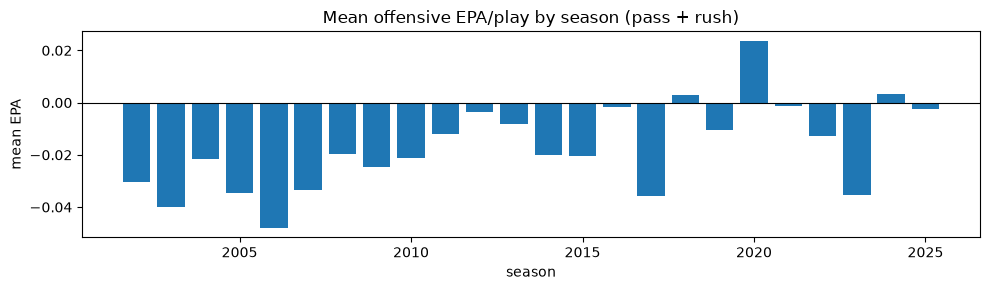

In [10]:
# Offensive EPA/play by season - should hover near zero with no cliffs/gaps
# that would signal missing or malformed data in a season.
off = plays[(plays.pass_attempt == 1) | (plays.rush_attempt == 1)]
season_epa = off.groupby("season").epa.mean()

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(season_epa.index.astype(int), season_epa.values)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Mean offensive EPA/play by season (pass + rush)")
ax.set_xlabel("season"); ax.set_ylabel("mean EPA")
plt.tight_layout()
season_epa.round(4)

## Summary

| Check | Expectation | Result | Verdict |
|---|---|---|---|
| Home win rate (all) | ~55–58% | 0.561 | ✅ |
| Home win rate (2023–24 test) | declined post-2019 | 0.544 | ✅ baseline read per-split |
| Avg total points | ~44–46 | 44.5 | ✅ |
| Avg home margin | ~2.5 | 2.2 | ✅ |
| Mean EPA/play | ≈ 0 | −0.007 | ✅ |
| Pass EPA vs rush EPA | pass > rush | +0.013 vs −0.057 | ✅ |
| CPOE mean | ≈ 0 | +0.12 pp | ✅ |
| Hardest down by EPA | 3rd down | −0.043 | ✅ |

Data is trustworthy. Cleared to start Phase 2 (feature pipeline, SPEC Section 5)
once given the go-ahead.